In [99]:
from __future__ import annotations

import csv
import statistics
from collections import defaultdict
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt


STAGES = ("node_pruned", "cluster_pruned", "local_vq_pruned", "record_pruned")
BREAKDOWN_STAGES = (*STAGES, "exact_evaluated")

STAGE_LABELS = {
    "node_pruned": "Node MBR lower bound",
    "cluster_pruned": "IVF Cluster bound",
    "local_vq_pruned": "local VQ",
    "record_pruned": "Lower Bounding Distance",
    "exact_evaluated": "True Distance",
}

STAGE_COLORS = {
    "node_pruned": "tab:blue",
    "cluster_pruned": "tab:orange",
    "local_vq_pruned": "tab:green",
    "record_pruned": "tab:red",
    "exact_evaluated": "tab:purple",
}

STAGE_TIMING_COLUMNS = {
    "node_pruned": "node_mbr_us",
    "cluster_pruned": "cluster_bound_us",
    "local_vq_pruned": "local_vq_us",
    "record_pruned": "record_bound_us",
    "exact_evaluated": "exact_distance_us",
}

TIMING_COLUMNS = (*STAGE_TIMING_COLUMNS.values(), "other_us")
REQUIRED_COLUMNS = {"query", "elapsed_ms", "total_records", *BREAKDOWN_STAGES}


def read_curve(path: Path | str) -> dict[int, list[dict[str, float]]]:
    path = Path(path)
    by_query: dict[int, list[dict[str, float]]] = defaultdict(list)

    with path.open(newline="") as stream:
        reader = csv.DictReader(stream)
        fields = set(reader.fieldnames or ())
        missing = REQUIRED_COLUMNS - fields

        if missing:
            raise ValueError(f"{path}: missing columns: {', '.join(sorted(missing))}")

        present_timing = set(TIMING_COLUMNS) & fields

        if present_timing and present_timing != set(TIMING_COLUMNS):
            missing_timing = set(TIMING_COLUMNS) - fields
            raise ValueError(f"{path}: incomplete stage-timing columns: {', '.join(sorted(missing_timing))}")

        for line_number, row in enumerate(reader, start=2):
            try:
                sample = {
                    name: float(row[name])
                    for name in ("elapsed_ms", "total_records", *BREAKDOWN_STAGES, *(TIMING_COLUMNS if present_timing else ()))
                }
                query = int(row["query"])
            except (KeyError, TypeError, ValueError) as error:
                raise ValueError(f"{path}:{line_number}: invalid curve row") from error

            if sample["total_records"] <= 0:
                raise ValueError(f"{path}:{line_number}: total_records must be positive")

            by_query[query].append(sample)

    if not by_query:
        raise ValueError(f"{path}: no samples")

    cleaned: dict[int, list[dict[str, float]]] = {}

    for query, samples in by_query.items():
        deduplicated: list[dict[str, float]] = []
        total_records = samples[0]["total_records"]
        previous_elapsed = -1.0
        previous_counts = {stage: 0.0 for stage in BREAKDOWN_STAGES}

        for sample in samples:
            elapsed = sample["elapsed_ms"]

            if elapsed < previous_elapsed:
                raise ValueError(f"{path}: query {query}: elapsed_ms decreases from {previous_elapsed:g} to {elapsed:g}")

            if sample["total_records"] != total_records:
                raise ValueError(f"{path}: query {query}: total_records changes within the query")

            for stage in BREAKDOWN_STAGES:
                count = sample[stage]

                if count < previous_counts[stage]:
                    raise ValueError(f"{path}: query {query}: {stage} decreases from {previous_counts[stage]:g} to {count:g}")

                previous_counts[stage] = count

            resolved = sum(sample[stage] for stage in BREAKDOWN_STAGES)

            if resolved > total_records + 0.5:
                raise ValueError(f"{path}: query {query}: cumulative stage counters exceed total_records ({resolved:g} > {total_records:g})")

            if deduplicated and elapsed == deduplicated[-1]["elapsed_ms"]:
                deduplicated[-1] = sample
            else:
                deduplicated.append(sample)

            previous_elapsed = elapsed

        final_resolved = sum(deduplicated[-1][stage] for stage in BREAKDOWN_STAGES)

        if abs(final_resolved - total_records) > 0.5:
            raise ValueError(
                f"{path}: query {query}: final stage counters account for "
                f"{final_resolved:g} of {total_records:g} records; the trace "
                "cannot produce a certified 100% staircase"
            )

        cleaned[query] = deduplicated

    return cleaned


def stage_timing_breakdown(
    curves: dict[int, list[dict[str, float]]],
    aggregate: str,
    query: int | None,
) -> tuple[list[tuple[str, float, float]], float, float]:
    if query is None:
        selected = curves
    else:
        if query not in curves:
            available = ", ".join(str(number) for number in sorted(curves))
            raise ValueError(f"query {query} is absent (available: {available})")

        selected = {query: curves[query]}

    reducer = statistics.median if aggregate == "median" else statistics.mean
    stage_summaries: list[tuple[str, float, float]] = []

    missing_timing = [
        query_number
        for query_number, samples in selected.items()
        if any(column not in samples[-1] for column in TIMING_COLUMNS)
    ]

    if missing_timing:
        raise ValueError("This breakdown requires a new per-query timing log. Rerun with --trie-pruning-curve after rebuilding the index executable.")

    for stage in BREAKDOWN_STAGES:
        contributions: list[float] = []
        durations: list[float] = []

        for samples in selected.values():
            total_records = samples[0]["total_records"]
            maximum = max(sample[stage] for sample in samples)
            contributions.append(100.0 * maximum / total_records)
            durations.append(samples[-1][STAGE_TIMING_COLUMNS[stage]] / 1000.0)

        contribution = reducer(contributions)
        duration = reducer(durations)

        if contribution > 1e-12 or duration > 1e-12:
            stage_summaries.append((stage, duration, contribution))

    other_time = reducer([samples[-1]["other_us"] / 1000.0 for samples in selected.values()])
    full_query_time = reducer([samples[-1]["elapsed_ms"] for samples in selected.values()])

    return stage_summaries, other_time, full_query_time


def plot_stage_staircase(
    ax,
    stage_summaries: Sequence[tuple[str, float, float]],
    other_time: float,
    full_query_time: float,
    *,
    annotated_stages: Sequence[str],
) -> None:
    if not stage_summaries:
        raise ValueError("The curve contains no stage contributions.")

    if full_query_time <= 0:
        raise ValueError("full_query_time must be positive")

    previous_time = 0.0
    cumulative = 0.0

    for stage, duration, contribution in stage_summaries:
        normalized_duration = 100.0 * duration / full_query_time
        timestamp = previous_time + normalized_duration
        next_cumulative = cumulative + contribution

        ax.plot([previous_time, timestamp, timestamp], [cumulative, cumulative, next_cumulative], color=STAGE_COLORS[stage], linewidth=2.5, solid_capstyle="butt", label=STAGE_LABELS[stage])

        if stage in annotated_stages:
            contribution_text = f"{contribution:.4f}%" if contribution < 0.01 else f"{contribution:.2f}%"
            near_endpoint = timestamp >= 82.0
            offset_x = -8 if near_endpoint else 8
            offset_y = -12 if next_cumulative > 96.0 else 0

            ax.annotate(
                f"{STAGE_LABELS[stage]}\n+{contribution_text}",
                xy=(timestamp, 0.5 * (cumulative + next_cumulative)),
                xytext=(offset_x, offset_y),
                textcoords="offset points",
                ha="right" if near_endpoint else "left",
                va="top" if offset_y < 0 else "center",
                color=STAGE_COLORS[stage],
                fontsize=8,
            )

        ax.scatter([timestamp], [next_cumulative], color=STAGE_COLORS[stage], s=25, zorder=3)

        previous_time = timestamp
        cumulative = next_cumulative

    normalized_other_time = 100.0 * other_time / full_query_time
    timed_runtime = previous_time + normalized_other_time

    if timed_runtime > 101.0:
        print(f"Warning: summed stage timings ({timed_runtime:.2f}%) exceed full query time (100%)")

    endpoint = 100.0

    if endpoint > previous_time:
        ax.plot([previous_time, endpoint], [cumulative, cumulative], color=STAGE_COLORS[stage_summaries[-1][0]], linewidth=2.5)

    ax.annotate(f"full query: {cumulative:.2f}%", xy=(endpoint, cumulative), xytext=(-6, 8), textcoords="offset points", ha="right", va="bottom", fontsize=9, fontweight="bold")
    ax.set_xlim(0, 100)


def plot_trie_pruning_curve(
    curve: Path | str,
    *,
    query: int | None = None,
    aggregate: str = "median",
    title: str = "Trie pruning breakdown",
    output: Path | str | None = None,
    figsize: tuple[float, float] = (8.0, 4.8),
    dpi: int = 180,
    annotation_column: str | None = None,
):
    if aggregate not in {"median", "mean"}:
        raise ValueError(f"aggregate must be 'median' or 'mean', got {aggregate!r}")

    curve = read_curve(curve)
    stages_to_annotate = (annotation_column,) if annotation_column is not None else BREAKDOWN_STAGES
    unknown = set(stages_to_annotate) - set(BREAKDOWN_STAGES)

    if unknown:
        raise ValueError("annotation_column must be a stage column: " + ", ".join(sorted(BREAKDOWN_STAGES)))

    stage_summaries, other_time, full_query_time = stage_timing_breakdown(curve, aggregate, query)
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    plot_stage_staircase(ax, stage_summaries, other_time, full_query_time, annotated_stages=stages_to_annotate)

    ylabel = f"{aggregate.capitalize()} cumulative records resolved (%)" if query is None else "Cumulative records resolved (%)"

    ax.set_title(title)
    ax.set_xlabel("Elapsed query time (%)")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 110)
    ax.set_xticks([0, 20, 40, 60, 80, 100])
    ax.set_xticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right")

    if output is not None:
        output = Path(output)
        output.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output, dpi=dpi)

    return fig, ax


def newest_curve(directory: Path | str) -> Path:
    directory = Path(directory)
    curves = list(directory.glob("MESSI_TRIE_PRUNING_CURVE_*.csv"))

    if not curves:
        raise FileNotFoundError(f"No pruning-curve CSV found in {directory}")

    return max(curves, key=lambda path: path.stat().st_mtime)


def newest_dataset_curve(dataset_directory: Path | str) -> Path | None:
    dataset_directory = Path(dataset_directory)
    curves = list(dataset_directory.glob("**/trie_pruning_curve/MESSI_TRIE_PRUNING_CURVE_*.csv"))
    return max(curves, key=lambda path: path.stat().st_mtime) if curves else None

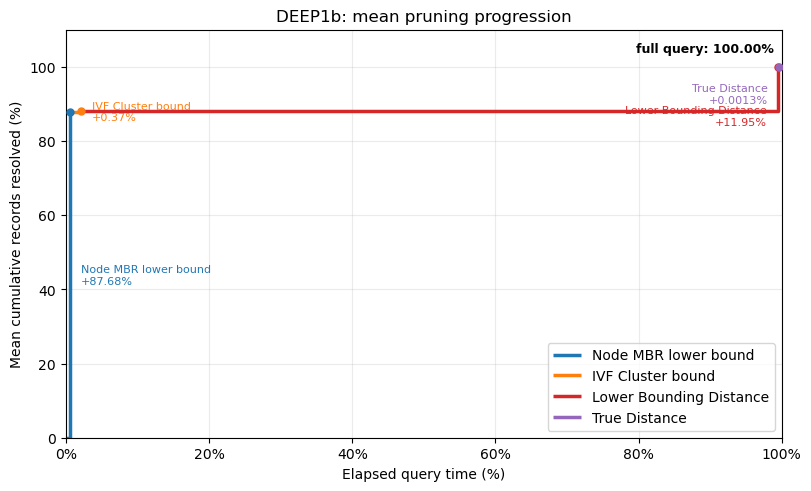

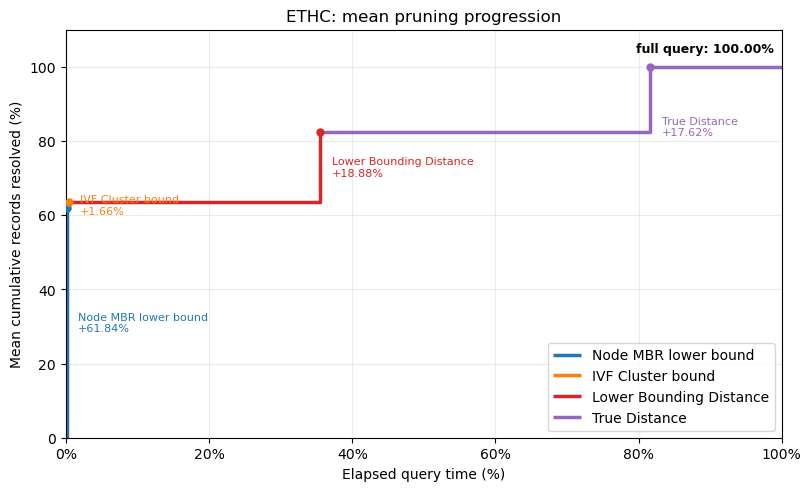

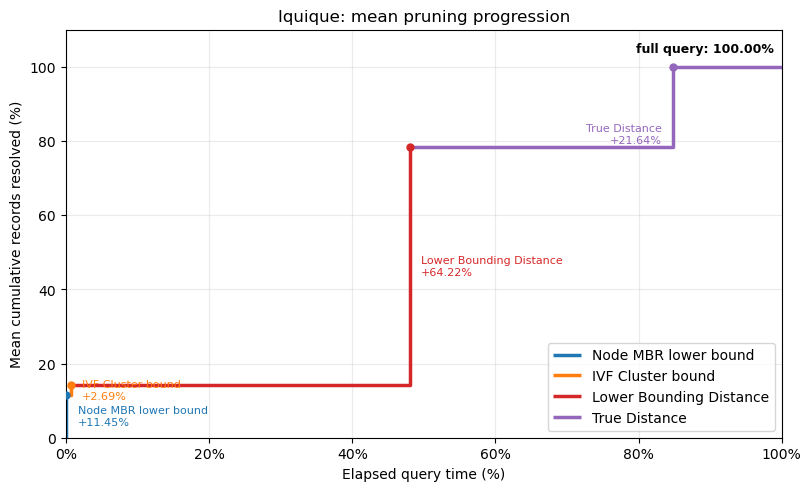

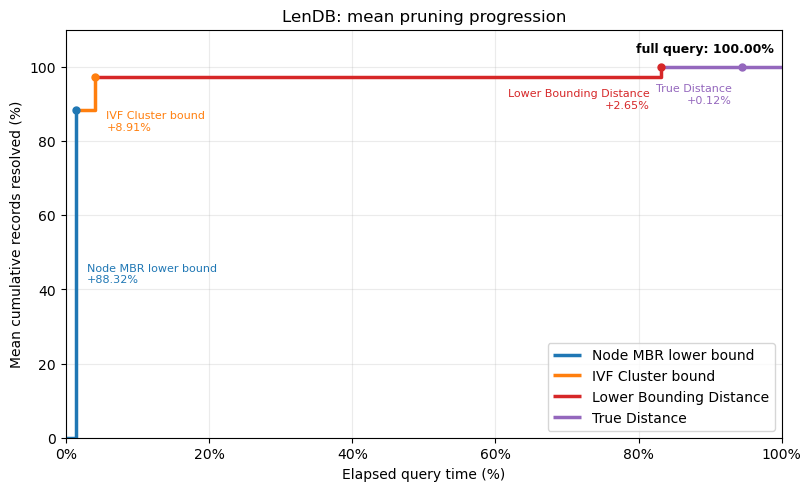

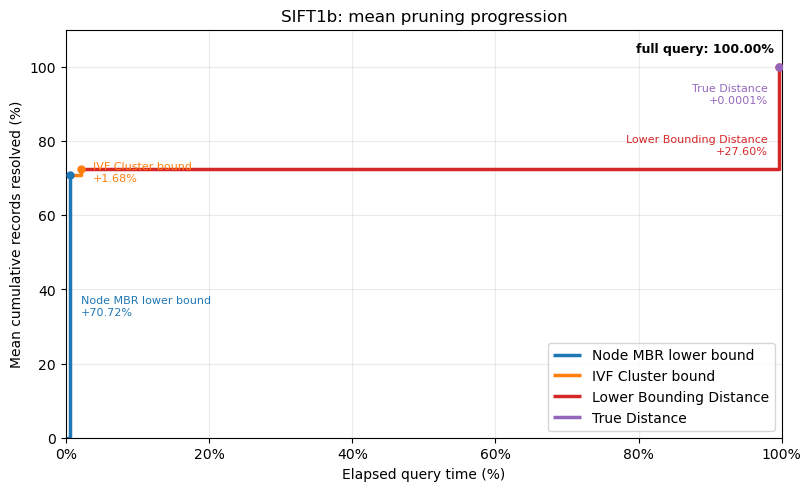

In [100]:
curve_root = Path("trie_pruning_curves")
if not curve_root.is_dir():
    raise FileNotFoundError(f"No trie-pruning-curves directory found at {curve_root}")

output_directory = curve_root / "plots"
for dataset_directory in sorted(curve_root.iterdir()):
    if not dataset_directory.is_dir() or dataset_directory.name == "plots":
        continue
    curve_file = newest_dataset_curve(dataset_directory)
    if curve_file is None:
        continue
    dataset = dataset_directory.name
    output = output_directory / f"{dataset}_pruning_staircase.png"
    fig, _ = plot_trie_pruning_curve(
        curve_file,
        aggregate="mean",
        title=f"{dataset}: mean pruning progression"
    )
    plt.show()